# Assignment 1 - Analyse Exploratoire des Données (EDA)

Ce notebook présente l'analyse de la base de données clinique de Cleveland. L'objectif est d'étudier la distribution de nos données médicales avant de les modéliser.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/Heart_disease_cleveland_new.csv')
print(f"Taille du dataset : {df.shape}")
display(df.head())

Taille du dataset : (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## 1. Qualité des données
Vérifions s'il y a des valeurs manquantes dans le dataset.

In [8]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ Le dataset de Cleveland est parfaitement propre (aucune donnée manquante).")
else:
    print(missing[missing > 0])

✅ Le dataset de Cleveland est parfaitement propre (aucune donnée manquante).


## 2. Équilibre des Classes
L'équilibre entre malades et sains est crucial pour le choix de notre métrique.

/var/folders/3m/gwf6hmxd66d5rbxk2p0b5ptr0000gn/T/ipykernel_70346/300627144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


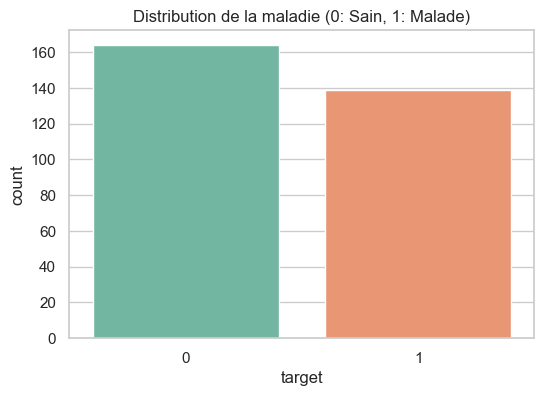

target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribution de la maladie (0: Sain, 1: Malade)')
plt.show()
print(df['target'].value_counts(normalize=True) * 100)

> **Insight** : Le dataset est équilibré (54% vs 46%). C'est une excellente nouvelle, pas besoin de suréchantillonner !

## 3. Analyse Univariée (Cholestérol)

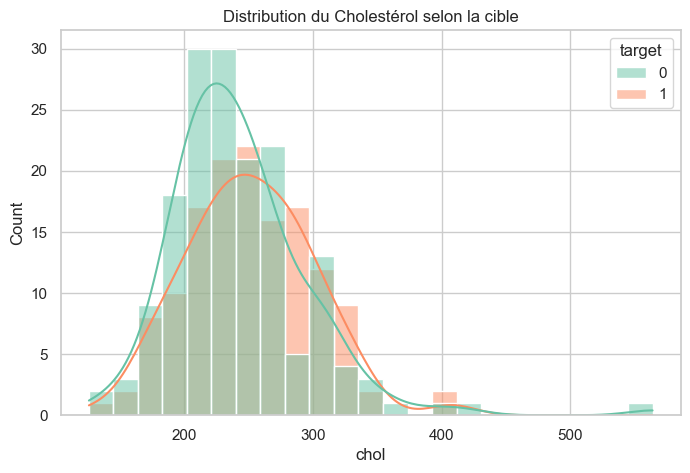

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='chol', hue='target', kde=True, palette='Set2')
plt.title('Distribution du Cholestérol selon la cible')
plt.show()

> **Insight** : Les distributions se chevauchent totalement. Le cholestérol seul ne suffit pas à diagnostiquer la maladie.

## 4. Corrélations Globales

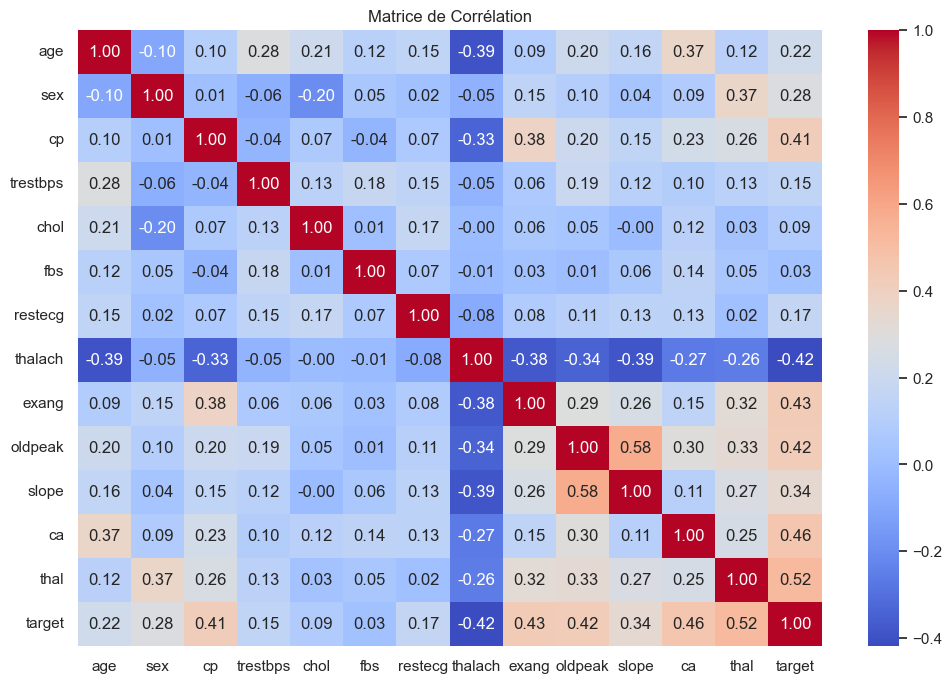

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()